## 02 Model training and evaluation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import f1_score, classification_report, accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, auc, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings('ignore')

In [3]:
path = 'C:/Users/' #needs to be updated

In [4]:
def split_df(df, x_scale=False):
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    if x_scale:
        scaler = StandardScaler()
        X_input = scaler.fit_transform(X)
    else:
        X_input = X
    
    X_train, X_test, y_train, y_test = train_test_split(X_input, y, test_size=0.2, random_state=31415)
    return X_train, X_test, y_train, y_test

In [5]:
#load bank-extended-full dataset
file_path = path+'bank-extended-full.csv'
df = pd.read_csv(file_path, sep=';')

In [6]:
#performing label encoding for categorical columns
df_enc = df.copy()

df_enc['y'] = df_enc['y'].map({'no': -1, 'yes': 1})
df_enc['education'] = df_enc['education'].map({'primary': 1, 'secondary': 2, 'tertiary': 3, 'unknown': -1})
df_enc['poutcome'] = df_enc['poutcome'].map({'success': 4, 'other': 3, 'failure': 2, 'no_contact': 1})
for col in ['housing', 'loan', 'default']:
    df_enc[col] = df_enc[col].map({'yes': 1, 'no': 0, 'unknown': -1})


le = LabelEncoder()
df_enc['job'] = le.fit_transform(df_enc['job'])
df_enc['marital'] = le.fit_transform(df_enc['marital'])
df_enc['contact'] = le.fit_transform(df_enc['contact'])

#alternative: one-hot-encoding
#df_enc = pd.get_dummies(df_enc, columns=['job'], prefix='job', dtype=int)
#df_enc = pd.get_dummies(df_enc, columns=['marital'], prefix='marital', dtype=int)
#df_enc = pd.get_dummies(df_enc, columns=['contact'], prefix='contact', dtype=int)


In [8]:
X_train, X_test, y_train, y_test = split_df(df_enc, x_scale=True)

### 02.1 Model training and comparison

In [125]:
def run_grid_search(model_name, grid_search_object, X, y):
    print(f"\n{'='*50}")
    print(f"GridSearch for {model_name}")
    print(f"{'='*50}")
    

    start_time = time.time() 
    print(f"Start Time: {time.strftime('%H:%M:%S', time.localtime(start_time))}")

    grid_search_object.fit(X, y)
    
    end_time = time.time()
    duration = end_time - start_time
    print(f"End Time: {time.strftime('%H:%M:%S', time.localtime(end_time))}")
    print(f"Total duration: {duration:.2f} seconds")
    
    results_df = pd.DataFrame(grid_search_object.cv_results_)
    top_results = results_df.sort_values(by='rank_test_score').head(3)
    
    print(f"\n--- TOP CONFIGURATIONS for {model_name} ---")
    for _, row in top_results.iterrows():
        print(f"Top {row['rank_test_score']}: ROC_AUC = {row['mean_test_score']:.4f}")
        print(f"Parameters: {row['params']}\n")
    
    return grid_search_object.best_estimator_


### 02.2 Logistic Regression

In [126]:
param_grid_lr = [
    {
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'], #support l1 and l2
        'C': [0.01, 0.1, 1, 10],
        'max_iter': [2000],
        'class_weight': ['balanced']
    },
    {
        'penalty': ['l2'],
        'solver': ['lbfgs', 'newton-cg', 'sag'], #support only l2
        'C': [0.01, 0.1, 1, 10],
        'max_iter': [2000],
        'class_weight': ['balanced']
    }
]

grid_lr = GridSearchCV(LogisticRegression(), param_grid_lr, scoring='roc_auc', cv=5, n_jobs=-1)
best_lr = run_grid_search("Logistic Regression", grid_lr, X_train, y_train)


GridSearch for Logistic Regression
Start Time: 21:38:50
End Time: 21:39:28
Total duration: 38.09 seconds

--- TOP CONFIGURATIONS for Logistic Regression ---
Top 1: ROC_AUC = 0.7790
Parameters: {'C': 10, 'class_weight': 'balanced', 'max_iter': 2000, 'penalty': 'l1', 'solver': 'liblinear'}

Top 2: ROC_AUC = 0.7790
Parameters: {'C': 10, 'class_weight': 'balanced', 'max_iter': 2000, 'penalty': 'l1', 'solver': 'saga'}

Top 3: ROC_AUC = 0.7790
Parameters: {'C': 10, 'class_weight': 'balanced', 'max_iter': 2000, 'penalty': 'l2', 'solver': 'sag'}



### 02.3 Random Forest

In [127]:
param_grid_rf = {
    'n_estimators': [200, 500],
    'max_depth': [None, 10, 20],
    'class_weight': ['balanced', 'balanced_subsample']
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=31415), param_grid_rf, scoring='roc_auc', cv=5)
best_rf = run_grid_search("Random Forest", grid_rf, X_train, y_train)


GridSearch for Random Forest
Start Time: 21:39:28
End Time: 21:46:50
Total duration: 441.86 seconds

--- TOP CONFIGURATIONS for Random Forest ---
Top 1: ROC_AUC = 0.8079
Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 500}

Top 2: ROC_AUC = 0.8079
Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 200}

Top 3: ROC_AUC = 0.8075
Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'n_estimators': 500}



### 02.4 Support Vector Machine

In [128]:
param_grid_svm = {
    'C': [0.1, 1],            
    'kernel': ['rbf', 'linear'],  
    'gamma': ['scale', 'auto'],   
    'class_weight': ['balanced']  
}

grid_svm = GridSearchCV(SVC(random_state=31415, probability=True, cache_size=500), param_grid_svm, scoring='roc_auc', cv=5, n_jobs=-1)
best_svm = run_grid_search("SVM", grid_svm, X_train, y_train)


GridSearch for SVM
Start Time: 21:46:50
End Time: 01:27:06
Total duration: 13216.17 seconds

--- TOP CONFIGURATIONS for SVM ---
Top 1: ROC_AUC = 0.7872
Parameters: {'C': 1, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}

Top 2: ROC_AUC = 0.7872
Parameters: {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}

Top 3: ROC_AUC = 0.7859
Parameters: {'C': 0.1, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}



### 02.5 Neural Network / Multi-Layer Perceptron

In [129]:
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50,), (100, 100,), (50, 100, 50,)],
    'alpha': [0.0001, 0.05],
    'learning_rate_init': [0.001, 0.01]
}

grid_mlp = GridSearchCV(estimator=MLPClassifier(max_iter=500, random_state=31415), param_grid=param_grid_mlp, scoring='roc_auc', cv=5, n_jobs=-1, verbose=1)
best_mlp = run_grid_search("MLP Classifier", grid_mlp, X_train, y_train)


GridSearch for MLP Classifier
Start Time: 01:27:06
Fitting 3 folds for each of 20 candidates, totalling 60 fits
End Time: 01:40:42
Total duration: 815.90 seconds

--- TOP CONFIGURATIONS for MLP Classifier ---
Top 1: ROC_AUC = 0.8028
Parameters: {'alpha': 0.05, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001}

Top 2: ROC_AUC = 0.8023
Parameters: {'alpha': 0.05, 'hidden_layer_sizes': (50, 100, 50), 'learning_rate_init': 0.01}

Top 3: ROC_AUC = 0.8012
Parameters: {'alpha': 0.05, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}



### 02.6 Model Evaluation

In [130]:
def evaluate_models(model_dict, X_test, y_test):
    comparison_list = []
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    for name, model in model_dict.items():
        
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred)
        
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        
        comparison_list.append({'Model': name, 'Test F1-Score': f1, 'Test ROC-AUC': auc})
        
        RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=f"{name} (AUC = {auc:.3f})")
    
    comparison_df = pd.DataFrame(comparison_list).sort_values(by='Test F1-Score', ascending=False)
    print("\n--- Model comparison F1-score (on test data) ---")
    print(comparison_df.to_string(index=False))
    
    ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
    ax.set_title("Model comparison ROC-Curve (on test data)")
    ax.legend()
    plt.show()
    
    return comparison_df


--- Model comparison F1-score (on test data) ---
              Model  Test F1-Score  Test ROC-AUC
      Random Forest       0.513281      0.808081
                SVM       0.493506      0.792691
Logistic Regression       0.440526      0.783183
     MLP Classifier       0.390847      0.807764


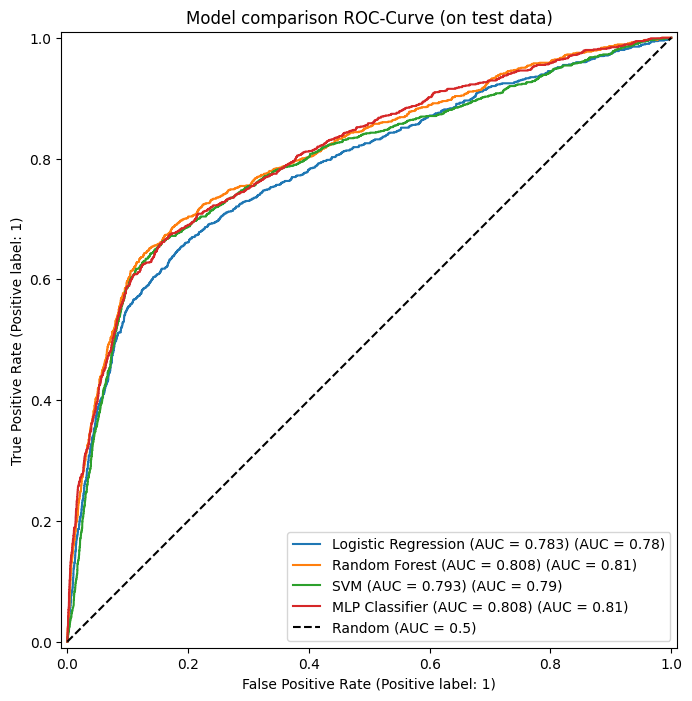

In [131]:
models_to_compare = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "SVM": best_svm,
    "MLP Classifier": best_mlp
}

final_results = evaluate_models(models_to_compare, X_test, y_test)

All models perform quite similarly considering the area under the ROC curve. <br>
Random Forest shows the best F1-Score and is therefore, based on this test and evaluation, the model of choice.